<a href="https://colab.research.google.com/github/01329582993/Bird-Species-Classification-ML/blob/main/notebooks/00_Project_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Setup
# Bird Species Classification using Classical Machine Learning

## Notebook 01 - Dataset Preparation


Objectives

- Study the CUB-200-2011 dataset
- Understand its structure
- Compute dataset statistics
- Analyze class distribution

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [25]:
import kagglehub

DATASET_PATH = kagglehub.dataset_download("wenewone/cub2002011")

print("Path to dataset files:", DATASET_PATH)

Using Colab cache for faster access to the 'cub2002011' dataset.
Path to dataset files: /kaggle/input/cub2002011


In [26]:
os.listdir(DATASET_PATH)

['cvpr2016_cub', 'CUB_200_2011', 'segmentations']

In [27]:
images = pd.read_csv(
    f"{DATASET_PATH}/CUB_200_2011/images.txt",
    sep=" ",
    names=["image_id", "image_path"]
)

classes = pd.read_csv(
    f"{DATASET_PATH}/CUB_200_2011/classes.txt",
    sep=" ",
    names=["class_id", "class_name"]
)

labels = pd.read_csv(
    f"{DATASET_PATH}/CUB_200_2011/image_class_labels.txt",
    sep=" ",
    names=["image_id", "class_id"]
)

In [28]:
classes.head()
print("Total Classes:", len(classes))

Total Classes: 200


In [29]:
images.head()
print("Total Images :", len(images))

images_per_class = labels["class_id"].value_counts().sort_index()

print("Minimum Images :", images_per_class.min())
print("Maximum Images :", images_per_class.max())
print("Average Images :", images_per_class.mean())

Total Images : 11788
Minimum Images : 41
Maximum Images : 60
Average Images : 58.94


In [30]:
labels.head()

,image_id,class_id
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


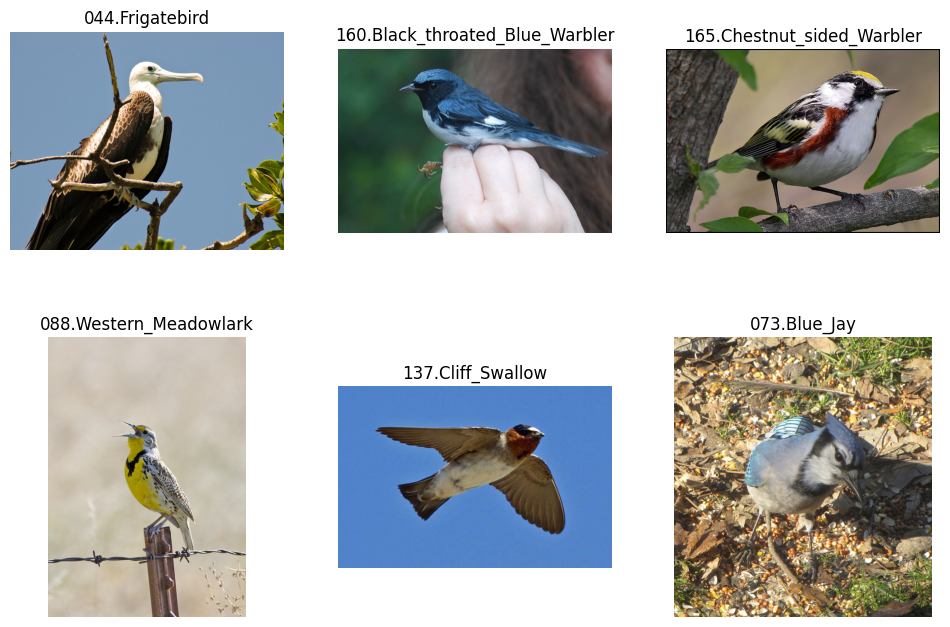

In [31]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax, (_, row) in zip(axes.flatten(), images.sample(6).iterrows()):

    img = Image.open(os.path.join(DATASET_PATH,"CUB_200_2011","images",row.image_path))

    ax.imshow(img)
    ax.set_title(row.image_path.split('/')[0])

    ax.axis("off")

plt.show()

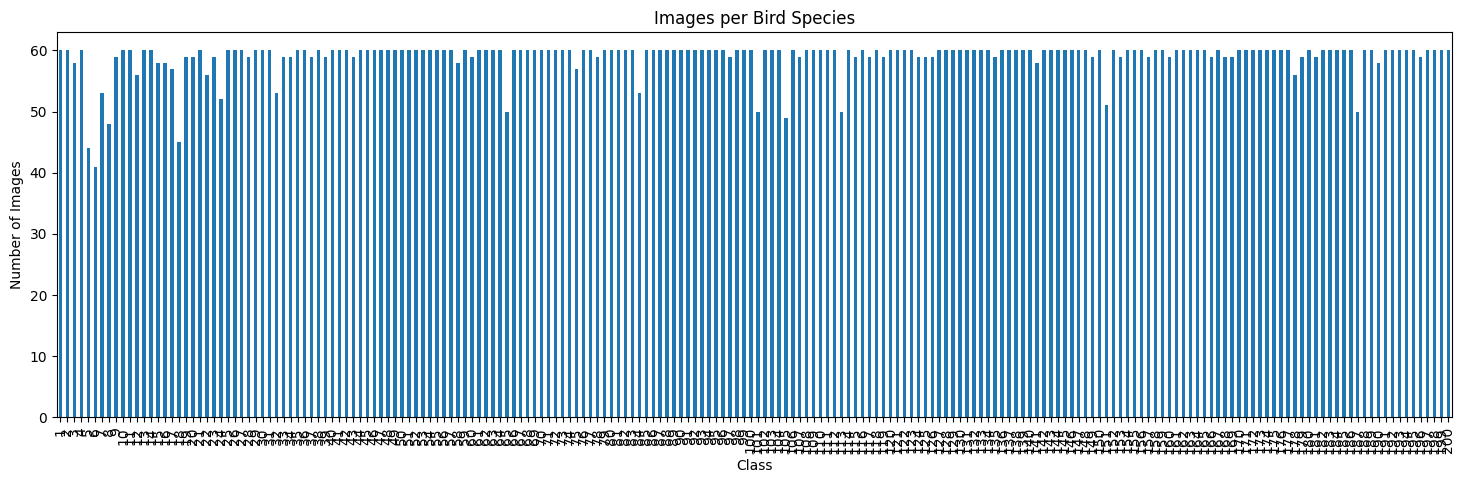

In [33]:
plt.figure(figsize=(18,5))

images_per_class.plot(kind="bar")

plt.title("Images per Bird Species")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.show()

## About CUB-200-2011

CUB-200-2011 (Caltech-UCSD Birds-200-2011) is a benchmark dataset
designed for fine-grained bird species classification.

It contains:

- 200 bird species
- 11,788 images
- Bounding box annotations
- Species labels
- Official train/test split

The dataset is widely used to evaluate image classification algorithms.